# Pertemuan 12: Pengantar Unsupervised Learning & K-Means Clustering

## Apa itu Unsupervised Learning?
Berbeda dengan Supervised Learning yang memiliki "kunci jawaban" (label/target), **Unsupervised Learning** bekerja dengan data yang tidak berlabel. Tujuannya adalah membiarkan mesin mencari tahu sendiri pola, struktur, atau kelompok tersembunyi di dalam data tersebut.

Salah satu teknik paling populer adalah **Clustering** (pengelompokan).

## Studi Kasus: Segmentasi Pelanggan Kedai Kopi
Bayangkan kita memiliki data pelanggan kedai kopi. Kita ingin membagi mereka ke dalam beberapa kelompok untuk strategi promo, berdasarkan:
1. **Belanja Kopi (Ribu Rp):** Seberapa banyak mereka menghabiskan uang untuk minuman kopi.
2. **Belanja Makanan (Ribu Rp):** Seberapa banyak mereka menghabiskan uang untuk makanan ringan/pastry.

Kita akan menggunakan algoritma **K-Means**. Algoritma ini bekerja dengan mencari titik pusat (*centroid*) untuk sejumlah $K$ kelompok, dan mengelompokkan setiap data ke *centroid* terdekat.

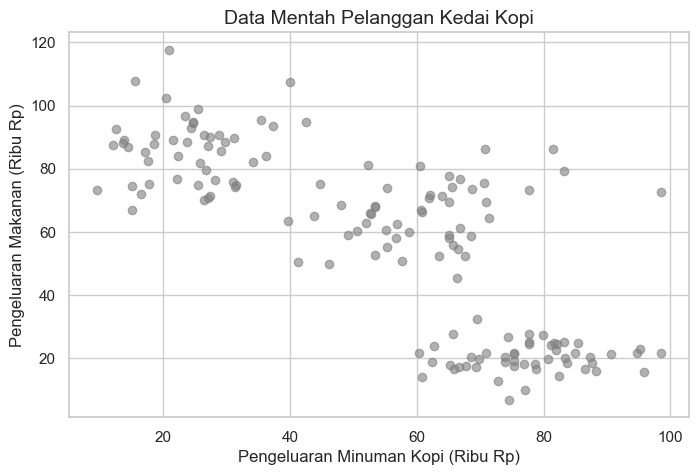

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set gaya visualisasi
sns.set_theme(style="whitegrid")

# 1. Membuat Dataset Dummy (Agar mudah dipahami tanpa perlu download file)
# Kita buat 3 kelompok pelanggan yang jelas
np.random.seed(42)

# Kelompok 1: Suka ngopi, jarang makan (Hanya beli minuman)
kopi_tinggi = np.random.normal(80, 10, 50)
makan_rendah = np.random.normal(20, 5, 50)

# Kelompok 2: Suka makan, jarang ngopi (Mungkin menemani teman)
kopi_rendah = np.random.normal(25, 8, 50)
makan_tinggi = np.random.normal(85, 12, 50)

# Kelompok 3: Suka dua-duanya (Beli paket lengkap)
kopi_sedang = np.random.normal(60, 10, 50)
makan_sedang = np.random.normal(65, 10, 50)

# Menggabungkan data menjadi satu DataFrame
kopi = np.concatenate([kopi_tinggi, kopi_rendah, kopi_sedang])
makanan = np.concatenate([makan_rendah, makan_tinggi, makan_sedang])

df_pelanggan = pd.DataFrame({
    'Belanja_Kopi': kopi,
    'Belanja_Makanan': makanan
})

# 2. Visualisasi Data Mentah (Belum dikelompokkan)
plt.figure(figsize=(8, 5))
plt.scatter(df_pelanggan['Belanja_Kopi'], df_pelanggan['Belanja_Makanan'], color='gray', alpha=0.6)
plt.title('Data Mentah Pelanggan Kedai Kopi', fontsize=14)
plt.xlabel('Pengeluaran Minuman Kopi (Ribu Rp)')
plt.ylabel('Pengeluaran Makanan (Ribu Rp)')
plt.show()

Sekarang, mari kita terapkan K-Means. Dari visualisasi di atas, mata kita secara natural bisa melihat ada 3 kelompok. Kita akan perintahkan K-Means untuk mencari 3 kelompok tersebut (`n_clusters=3`).

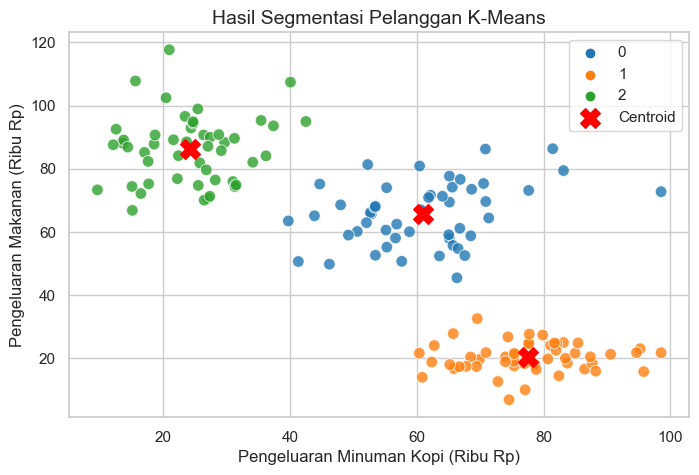

In [2]:
# 3. Menerapkan K-Means Clustering
# Inisialisasi model dengan 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Melatih model dan langsung mendapatkan label cluster untuk setiap pelanggan
df_pelanggan['Cluster'] = kmeans.fit_predict(df_pelanggan[['Belanja_Kopi', 'Belanja_Makanan']])

# Mendapatkan titik pusat (centroid) dari masing-masing cluster
centroids = kmeans.cluster_centers_

# 4. Visualisasi Hasil K-Means
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pelanggan, 
    x='Belanja_Kopi', 
    y='Belanja_Makanan', 
    hue='Cluster', 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'], 
    s=70, 
    alpha=0.8
)

# Menandai centroid dengan tanda 'X' merah
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroid')

plt.title('Hasil Segmentasi Pelanggan K-Means', fontsize=14)
plt.xlabel('Pengeluaran Minuman Kopi (Ribu Rp)')
plt.ylabel('Pengeluaran Makanan (Ribu Rp)')
plt.legend()
plt.show()

# Pertemuan 13: Hierarchical Clustering & Evaluasi

## Pendekatan Berbeda: Hierarchical Clustering
Jika K-Means memerlukan kita untuk menentukan jumlah $K$ di awal, **Hierarchical Clustering** (khususnya *Agglomerative*) bekerja dari bawah ke atas (*bottom-up*). 
1. Awalnya, setiap pelanggan dianggap sebagai 1 cluster terpisah.
2. Secara bertahap, pelanggan yang paling mirip (jaraknya paling dekat) digabungkan menjadi satu cluster.
3. Proses ini berlanjut sampai semua bergabung menjadi satu cluster besar.

Proses ini sangat bagus divisualisasikan dengan **Dendrogram**, yang menyerupai silsilah pohon. Dendrogram membantu kita memutuskan jumlah cluster optimal dengan memotong pohon tersebut pada ketinggian tertentu.

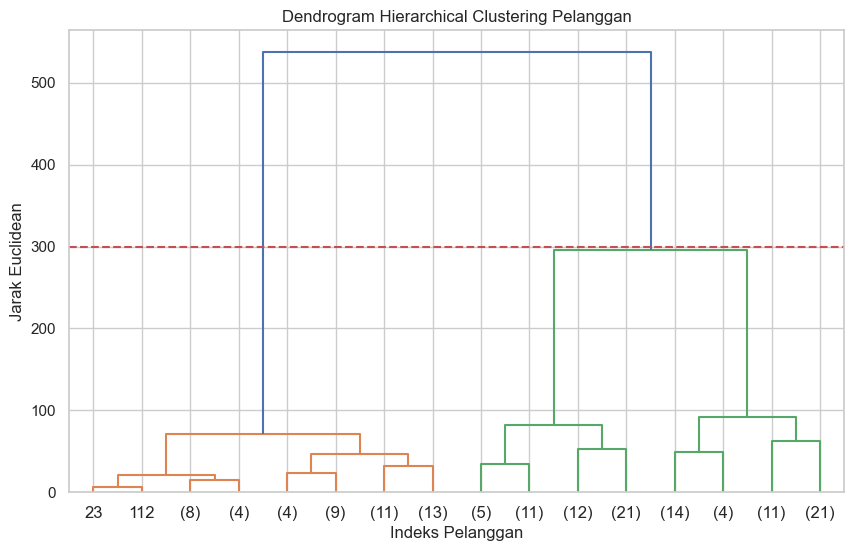

In [3]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Membuat Dendrogram
plt.figure(figsize=(10, 6))
plt.title('Dendrogram Hierarchical Clustering Pelanggan')
plt.xlabel('Indeks Pelanggan')
plt.ylabel('Jarak Euclidean')

# Menghitung linkage (jarak antar cluster) menggunakan metode 'ward'
Z = sch.linkage(df_pelanggan[['Belanja_Kopi', 'Belanja_Makanan']], method='ward')
dendrogram = sch.dendrogram(Z, truncate_mode='level', p=3)
plt.axhline(y=300, color='r', linestyle='--') # Garis potong imajiner untuk 3 cluster
plt.show()

Dari dendrogram di atas, memotong pada jarak Euclidean tertentu (garis putus-putus merah) menghasilkan 3 cabang utama. Mari kita terapkan modelnya.

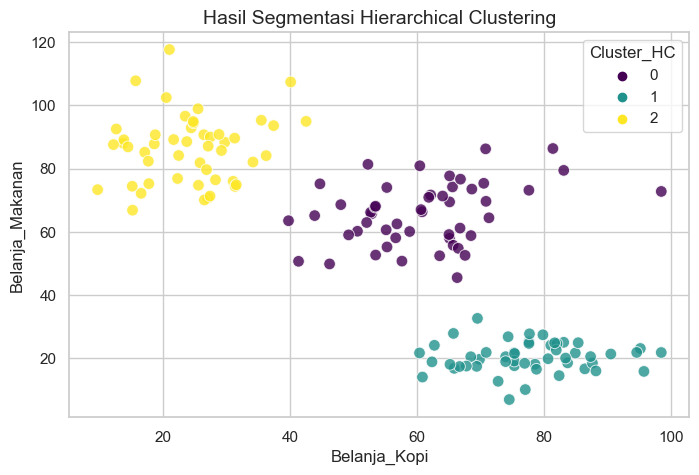

Evaluasi Kualitas Cluster:
Silhouette Score K-Means: 0.637
Silhouette Score Hierarchical: 0.637


In [4]:
# 2. Menerapkan Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_pelanggan['Cluster_HC'] = hc.fit_predict(df_pelanggan[['Belanja_Kopi', 'Belanja_Makanan']])

# Visualisasi Hasil Hierarchical Clustering
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pelanggan, 
    x='Belanja_Kopi', 
    y='Belanja_Makanan', 
    hue='Cluster_HC', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.title('Hasil Segmentasi Hierarchical Clustering', fontsize=14)
plt.show()

# 3. Evaluasi Model: Silhouette Score
# Silhouette score mengukur seberapa dekat sebuah data dengan cluster-nya sendiri 
# dibandingkan dengan cluster lain. Nilainya dari -1 hingga 1 (Mendekati 1 = Sangat baik).
score_kmeans = silhouette_score(df_pelanggan[['Belanja_Kopi', 'Belanja_Makanan']], df_pelanggan['Cluster'])
score_hc = silhouette_score(df_pelanggan[['Belanja_Kopi', 'Belanja_Makanan']], df_pelanggan['Cluster_HC'])

print(f"Evaluasi Kualitas Cluster:")
print(f"Silhouette Score K-Means: {score_kmeans:.3f}")
print(f"Silhouette Score Hierarchical: {score_hc:.3f}")

## Kesimpulan
Melalui Unsupervised Learning, kita berhasil menemukan 3 profil pelanggan tanpa harus memberi label pada data mentah secara manual:
1. **Cluster Kopi Lovers:** Pengeluaran kopi tinggi, makanan rendah. *(Cocok diberi promo beli kopi gratis *upsize*).*
2. **Cluster Pencari Cemilan:** Pengeluaran makanan tinggi, kopi rendah. *(Cocok diberi promo diskon pastry).*
3. **Cluster Big Spender:** Pengeluaran seimbang dan tinggi. *(Cocok untuk program loyalitas pelanggan/VIP).*